# SIT307 – Machine Learning
## 8.1D: Machine Learning Mini Project
### Sydney Housing Price Prediction and Decision Support System

**Student Name:** Thamasha Kavindhi  | s226057302
**Project:** Sydney Housing Price Prediction and Decision Support System

---

## 1. Introduction

Housing prices can vary significantly depending on factors such as location, property type, size, number of bedrooms and other property characteristics. In this project, I investigate whether machine learning can be used to understand these relationships and predict the sale price of residential properties in Sydney.

I selected **Parramatta, Blacktown and Bondi** because they represent different areas of the Sydney housing market. Parramatta is a major urban centre with a large number of apartments, Blacktown contains more suburban family homes and relatively affordable properties, while Bondi represents a higher-priced market closer to Sydney's eastern coastline. Using these different suburbs should help me investigate how location and property characteristics influence sale prices.

The project follows the main stages of a machine learning workflow. I first collect and clean sold-property data, explore the dataset and investigate important patterns, and then perform feature engineering. After this, I develop and compare three regression models using cross-validation and suitable regression metrics. I also investigate properties where the selected model produces large prediction errors.

Finally, I use the developed model in a simple web-based application where property information can be entered to obtain an estimated sale price. The purpose is not only to find an accurate model, but also to understand its behaviour, limitations and usefulness for property valuation.

## 2. Problem Definition and Data Collection

The target variable for this project is **sale price**, making this a supervised regression problem.

I selected three Sydney suburbs:

- **Parramatta** – an urban market containing many apartments as well as houses and townhouses.
- **Blacktown** – a suburban market with a larger proportion of detached family homes and townhouses.
- **Bondi** – a higher-priced eastern Sydney market containing apartments and premium residential properties.

The property data was manually collected from publicly available sold-property listings. For each property, I recorded available characteristics such as the suburb, sale price, sale date, property type, bedrooms, bathrooms, car spaces and property size.

During collection, some listings did not provide all property characteristics. In particular, property size and parking information were not consistently available. Properties without a disclosed sale price were not suitable for supervised model training because the target value was unavailable. Duplicate records were also checked so that the same property sale would not be represented more than once.

Missing or questionable values were not manually invented. They were retained as missing values so that they could be investigated and handled systematically during the preprocessing stage.

## 3. Data Understanding and Preprocessing

Before developing any machine learning models, I first import the required Python libraries and inspect the collected dataset. This allows me to understand the structure of the data, identify missing values and duplicates, examine data types and check whether any cleaning is required before performing exploratory analysis.

In [1]:
# Libraries for data handling and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


### Library Setup

The required Python libraries were imported successfully. Pandas and NumPy will be used for data handling and numerical operations, while Matplotlib will be used to create visualisations during the exploratory data analysis.

### Loading the Housing Dataset

The collected housing dataset is loaded into a Pandas DataFrame. I first display a sample of the dataset to confirm that the CSV file has been loaded correctly and to inspect how the property information is organised.

In [3]:
# Load the collected Sydney housing dataset
df = pd.read_csv("sydney_housing.csv")

# Display the first five properties
df.head()

,id,address,suburb,sale_price,sale_date,property_type,bedrooms,bathrooms,car_spaces,property_size_m2
0,1,4/44-50 Thomas Street,Parramatta,720000,2026-09-16,Townhouse,2,1,1.0,128.0
1,2,2315/45 Macquarie Street,Parramatta,640000,2026-09-16,Apartment,2,2,1.0,NaN
2,3,1/3 Stewart Street,Parramatta,570000,2026-09-16,Apartment,2,1,1.0,NaN
3,4,641/180 George Street,Parramatta,600000,2026-09-16,Apartment,2,1,NaN,NaN
4,5,610/36-46 Cowper Street,Parramatta,575000,2026-09-14,Apartment,2,2,1.0,NaN


### Initial Dataset Preview

The dataset was loaded successfully and the first five records confirm that the expected property information is available. The dataset contains identifiers, addresses, suburb information, sale prices, sale dates, property types, bedrooms, bathrooms, car spaces and property size.

The initial preview also shows that some property characteristics contain missing values (`NaN`). For example, property size is unavailable for several of the displayed properties, and parking information is also missing for one property. These values will need to be investigated before deciding how they should be handled during preprocessing.

### Dataset Size and Suburb Distribution

I next examine the size of the dataset and the number of observations collected from each suburb. This is important because the project requires at least 100 sold properties in total, with a minimum of 30 properties from each selected suburb.

In [4]:
# Check the size of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Check the number of properties from each suburb
print("\nProperties per suburb:")
print(df["suburb"].value_counts())

Number of rows: 100
Number of columns: 10

Properties per suburb:
suburb
Parramatta    35
Blacktown     34
Bondi         31
Name: count, dtype: int64


### Dataset Size Check

The final dataset contains 100 sold properties and 10 variables. The observations are distributed across the three selected suburbs, with 35 properties from Parramatta, 34 from Blacktown and 31 from Bondi.

This confirms that the final dataset satisfies the project requirement of at least 100 sold properties overall and a minimum of 30 properties from each selected suburb. The relatively balanced distribution also provides observations from all three housing markets for the following exploratory analysis and modelling stages.

### Data Types and Missing Values

Before cleaning the dataset, I examine the data types of each variable and count the missing values. This helps identify whether any variables need type conversion and which property characteristics require missing-value handling before exploratory analysis and model development.

In [5]:
# Check the structure and data types
print("Dataset information:")
df.info()

# Count missing values in each column
print("\nMissing values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                100 non-null    int64  
 1   address           100 non-null    object 
 2   suburb            100 non-null    object 
 3   sale_price        100 non-null    int64  
 4   sale_date         100 non-null    object 
 5   property_type     100 non-null    object 
 6   bedrooms          100 non-null    int64  
 7   bathrooms         100 non-null    int64  
 8   car_spaces        87 non-null     float64
 9   property_size_m2  34 non-null     float64
dtypes: float64(2), int64(4), object(4)
memory usage: 7.9+ KB

Missing values:
id                   0
address              0
suburb               0
sale_price           0
sale_date            0
property_type        0
bedrooms             0
bathrooms            0
car_spaces          13
property_size_m2    66
dt

### Data Quality Findings

The dataset contains 100 observations across 10 variables. Most variables are complete, including the target variable `sale_price`, suburb, property type, bedrooms and bathrooms. No duplicate rows were detected.

Two variables contain missing information. `car_spaces` has 13 missing values, while `property_size_m2` has 66 missing values. The large amount of missing property-size information is an important limitation of the collected data and needs to be considered carefully rather than simply removing all affected properties.

The inspection also shows that `sale_date` is currently stored as an object rather than a date variable. Therefore, it will be converted to a datetime format before analysing changes in sale prices over time.

### Data Cleaning and Preparation

Based on the initial inspection, I perform several preparation steps before exploratory analysis. The sale date is converted into a datetime format so that time-based patterns can be investigated.

For the missing numerical property characteristics, I retain the observations rather than removing them. Removing every property with a missing size would discard a large proportion of the dataset. Missing values will therefore be handled appropriately during the modelling stage. The `id` and `address` variables are retained for identifying individual properties, but they will not be used directly as predictive features.

In [6]:
# Create a copy before preprocessing
df_clean = df.copy()

# Convert sale date to datetime format
df_clean["sale_date"] = pd.to_datetime(df_clean["sale_date"])

# Check the conversion
print("Sale date data type:", df_clean["sale_date"].dtype)

# Display the range of sale dates
print("Earliest sale:", df_clean["sale_date"].min())
print("Latest sale:", df_clean["sale_date"].max())

# Confirm dataset size after preparation
print("\nDataset shape:", df_clean.shape)

Sale date data type: datetime64[ns]
Earliest sale: 2025-10-24 00:00:00
Latest sale: 2026-09-17 00:00:00

Dataset shape: (100, 10)


### Preparation Result

The `sale_date` variable was successfully converted to a datetime format. The sales in the dataset range from 24 October 2025 to 17 September 2026, allowing the timing of property sales to be considered during the analysis.

The dataset remains at 100 observations and 10 variables after this preparation step. No records were removed at this stage because the available observations are still useful even when some property characteristics are missing.

## 4. Exploratory Data Analysis

Before developing the regression models, I explore the dataset to understand the main patterns in Sydney property prices. I focus on the overall distribution of sale prices, differences between the three suburbs, changes over time and possible unusual or extreme properties.

Before performing feature engineering, I expect the following three variables to have the strongest influence on sale price:

1. **Suburb** – location is likely to have a strong effect because Parramatta, Blacktown and Bondi represent different housing markets.
2. **Property type** – houses, townhouses and apartments may have different price ranges because they provide different amounts of land, space and privacy.
3. **Property size** – larger properties would generally be expected to have higher sale prices, although this variable contains substantial missing information in the collected dataset.

These are initial expectations made before feature engineering and modelling. I will later compare them with the patterns found in the data and the behaviour of the developed models.

### Sale Price Distribution

I first examine the distribution of the target variable, `sale_price`. This helps identify the typical price range in the dataset, the spread of property prices and whether there are unusually expensive or inexpensive properties that may influence the regression models.

Sale Price Summary:
count    1.000000e+02
mean     1.248695e+06
std      1.019964e+06
min      2.500000e+05
25%      5.787500e+05
50%      8.540000e+05
75%      1.561500e+06
max      5.416000e+06
Name: sale_price, dtype: float64


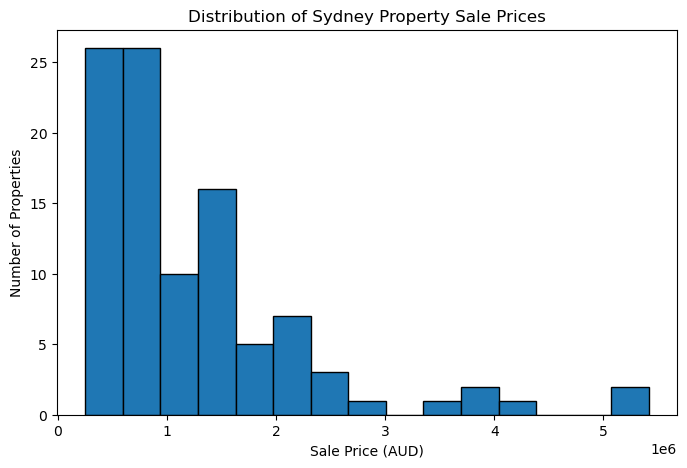

In [7]:
# Summary statistics for sale price
print("Sale Price Summary:")
print(df_clean["sale_price"].describe())

# Plot the distribution of sale prices
plt.figure(figsize=(8, 5))
plt.hist(df_clean["sale_price"], bins=15, edgecolor="black")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sydney Property Sale Prices")
plt.show()

### Sale Price Distribution Findings

The 100 properties have sale prices ranging from $250,000 to $5,416,000. The median sale price is $850,000, while the mean is approximately $1.25 million. The mean being considerably higher than the median indicates that the price distribution is right-skewed.

The histogram supports this observation. Most properties are concentrated in the lower and middle price ranges, while a smaller number of properties have sale prices above $3 million, including properties exceeding $5 million. These high-value properties may behave as outliers and could have a strong influence on regression models and error metrics. I will investigate these unusual properties further during the analysis.

### Sale Prices by Suburb

I next compare sale prices across Parramatta, Blacktown and Bondi. Since the three suburbs were selected to represent different housing markets, I expect noticeable differences in their typical sale prices and price ranges.

I use summary statistics together with a box plot to compare the distributions and identify whether particular suburbs contain unusually high-priced properties.

Sale Price Summary by Suburb:
            count        mean     median     min      max
suburb                                                   
Blacktown      34   882147.06   816500.0  375000  1900000
Bondi          31  2228790.32  1760000.0  650000  5416000
Parramatta     35   736685.71   600000.0  250000  2300000


<Figure size 800x500 with 0 Axes>

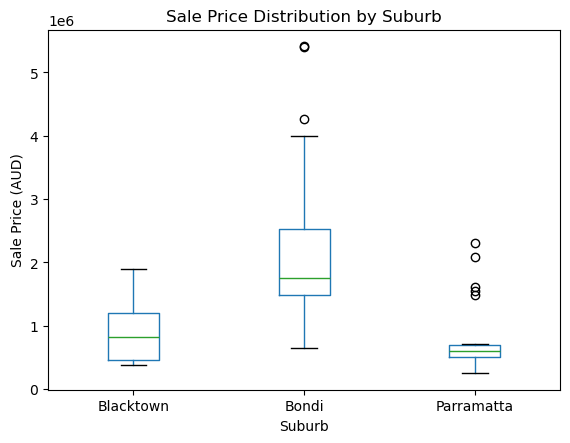

In [8]:
# Calculate sale price statistics for each suburb
suburb_summary = df_clean.groupby("suburb")["sale_price"].agg(
    ["count", "mean", "median", "min", "max"]
)

print("Sale Price Summary by Suburb:")
print(suburb_summary.round(2))

# Compare sale price distributions using a box plot
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="sale_price",
    by="suburb",
    grid=False
)

plt.title("Sale Price Distribution by Suburb")
plt.suptitle("")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.show()

### Suburb Comparison Findings

The results show a clear difference in property prices between the three suburbs. Bondi has the highest typical prices, with a median sale price of $1.76 million and an average of approximately $2.23 million. Blacktown has a median of $816,500, while Parramatta has the lowest median at $600,000.

Bondi also shows the greatest price spread, with sales ranging from $650,000 to $5.416 million. The box plot highlights several high-value properties, particularly in Bondi and Parramatta. These results support my initial expectation that suburb is likely to be an important predictor of sale price. However, the variation within each suburb also suggests that location alone cannot explain property prices.

### Sale Prices by Property Type

Property type was another variable that I expected to have a strong influence on sale price. I compare the available property categories to investigate whether houses, apartments, townhouses and other property types show different price patterns.

Properties by Type:
property_type
Apartment        64
House            27
Townhouse         7
Studio            1
Semi-detached     1
Name: count, dtype: int64

Sale Price Summary by Property Type:
               count        mean     median      min      max
property_type                                                
Semi-detached      1  2750000.00  2750000.0  2750000  2750000
House             27  2054574.07  1480000.0   880000  5416000
Townhouse          7   762928.57   765000.0   700000   828000
Apartment         64   953992.19   645500.0   300000  2600000
Studio             1   250000.00   250000.0   250000   250000


<Figure size 900x500 with 0 Axes>

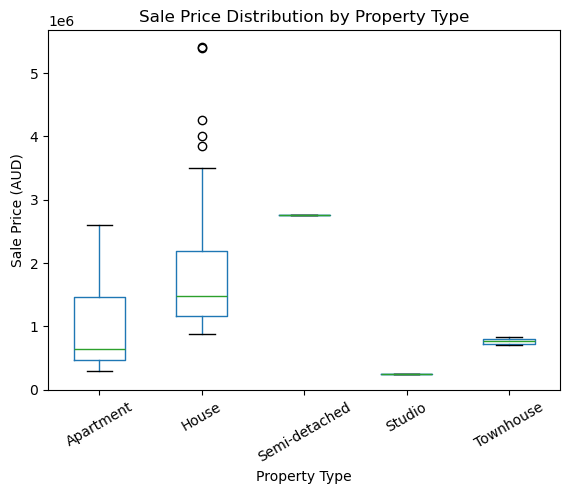

In [9]:
# Check the number of properties in each property type
print("Properties by Type:")
print(df_clean["property_type"].value_counts())

# Calculate median and mean sale price by property type
type_summary = df_clean.groupby("property_type")["sale_price"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("median", ascending=False)

print("\nSale Price Summary by Property Type:")
print(type_summary.round(2))

# Box plot of sale prices by property type
plt.figure(figsize=(9, 5))

df_clean.boxplot(
    column="sale_price",
    by="property_type",
    grid=False
)

plt.title("Sale Price Distribution by Property Type")
plt.suptitle("")
plt.xlabel("Property Type")
plt.ylabel("Sale Price (AUD)")
plt.xticks(rotation=30)
plt.show()

### Property Type Findings

Property type shows noticeable differences in sale prices. Apartments are the most common property type in the dataset, with 64 observations and a median sale price of $655,000. Houses have a much higher median price of $1.48 million across 27 observations, while the seven townhouses have a median price of $765,000.

The box plot also shows a wider price range among houses, including several high-value properties above $3 million. This supports my initial expectation that property type is likely to influence sale price. However, the semi-detached and studio categories each contain only one observation, so their prices cannot be considered representative of those property types generally.

### Property Size and Sale Price

Property size was the third variable that I expected to have a strong influence on sale price. To investigate this relationship, I compare property size with sale price using only observations where size information is available.

Since property size is missing for 66 properties, this analysis is based on a smaller subset of the dataset. Therefore, any relationship observed should be interpreted with caution.

Properties with size information: 34
Correlation between property size and sale price: 0.209


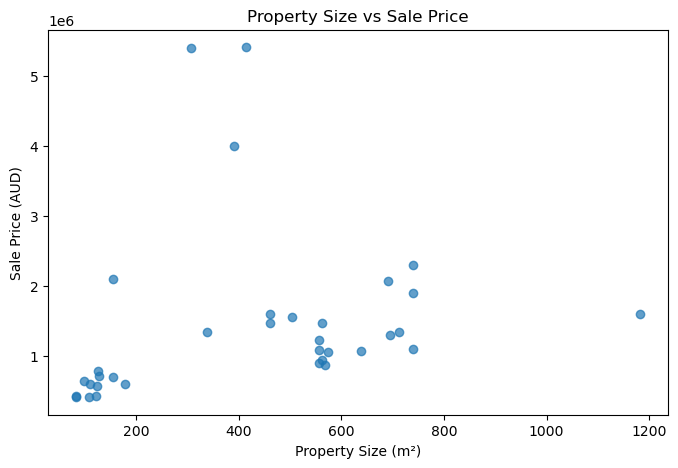

In [10]:
# Select properties with available size information
size_data = df_clean.dropna(subset=["property_size_m2"])

print("Properties with size information:", len(size_data))

# Calculate correlation between size and sale price
size_correlation = size_data["property_size_m2"].corr(
    size_data["sale_price"]
)

print("Correlation between property size and sale price:",
      round(size_correlation, 3))

# Scatter plot
plt.figure(figsize=(8, 5))

plt.scatter(
    size_data["property_size_m2"],
    size_data["sale_price"],
    alpha=0.7
)

plt.xlabel("Property Size (m²)")
plt.ylabel("Sale Price (AUD)")
plt.title("Property Size vs Sale Price")
plt.show()

### Property Size Findings

Property size has a correlation of 0.209 with sale price among the 34 properties where size information is available. This indicates only a weak positive relationship in the available data. Although some larger properties have higher prices, the scatter plot shows substantial variation and several smaller properties with very high sale prices.

This result does not strongly support my initial expectation that property size would be one of the strongest predictors. Location, property type and other characteristics may explain some of the variation that size alone cannot capture. This result must also be interpreted cautiously because property size is available for only 34% of the dataset.

### Sale Price Trends Over Time

I next investigate whether sale prices show any visible changes over the period covered by the dataset. Since the three suburbs have very different price levels, I examine the monthly median sale price separately for each suburb rather than combining all properties into a single trend.

Monthly Median Sale Prices:
suburb      Blacktown      Bondi  Parramatta
sale_month                                  
2025-10           NaN        NaN    586000.0
2026-04           NaN  1650000.0         NaN
2026-05           NaN  1450000.0         NaN
2026-06           NaN  2032500.0   1480000.0
2026-07           NaN        NaN   1955000.0
2026-08      805000.0  2750000.0    620500.0
2026-09      828000.0  2300000.0    590000.0


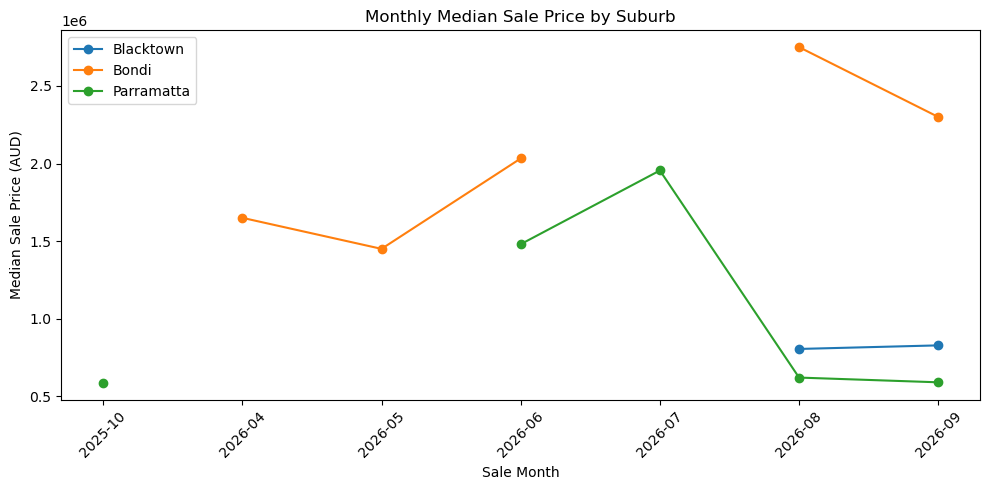

In [11]:
# Create a month variable for time-based analysis
df_clean["sale_month"] = df_clean["sale_date"].dt.to_period("M").astype(str)

# Calculate monthly median price for each suburb
monthly_prices = df_clean.groupby(
    ["sale_month", "suburb"]
)["sale_price"].median().unstack()

print("Monthly Median Sale Prices:")
print(monthly_prices)

# Plot monthly median prices
plt.figure(figsize=(10, 5))

for suburb in monthly_prices.columns:
    plt.plot(
        monthly_prices.index,
        monthly_prices[suburb],
        marker="o",
        label=suburb
    )

plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price (AUD)")
plt.title("Monthly Median Sale Price by Suburb")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### Time Trend Findings

The monthly results show that the sales are not evenly spread across all months. Some suburbs have no sales recorded in certain months, so it is difficult to make a strong comparison across the whole time period.

From the available data, Bondi generally has higher median prices than the other two suburbs. Blacktown stays fairly similar between August and September 2026, while Parramatta shows more variation between the months available.

Because this dataset only contains 100 manually collected properties, I do not think these results are enough to represent the overall Sydney housing market. However, the sale date may still provide useful information when developing the prediction models.

### Identification of Price Outliers

From the previous graphs, I noticed that a few properties have much higher sale prices compared with most of the dataset. I use the IQR method to identify these possible outliers more clearly.

I do not remove these properties straight away because a high price does not necessarily mean that the data is incorrect. For example, it could be a larger house or a premium property in an expensive suburb. I first look at these properties and their characteristics before deciding how they should be handled.

In [13]:
# Calculate IQR for sale price
Q1 = df_clean["sale_price"].quantile(0.25)
Q3 = df_clean["sale_price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify potential price outliers
price_outliers = df_clean[
    (df_clean["sale_price"] < lower_bound) |
    (df_clean["sale_price"] > upper_bound)
].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("\nNumber of potential price outliers:", len(price_outliers))

# Display their main characteristics
price_outliers[
    [
        "address",
        "suburb",
        "sale_price",
        "property_type",
        "bedrooms",
        "bathrooms",
        "property_size_m2"
    ]
].sort_values("sale_price", ascending=False)

Q1: 578750.0
Q3: 1561500.0
IQR: 982750.0
Lower bound: -895375.0
Upper bound: 3035625.0

Number of potential price outliers: 6


,address,suburb,sale_price,property_type,bedrooms,bathrooms,property_size_m2
81,14 Anglesea Street,Bondi,5416000,House,6,4,415.0
70,1 Miller Street,Bondi,5400000,House,5,4,307.0
76,38 Philip Street,Bondi,4260000,House,3,2,NaN
72,3 Flood Street,Bondi,4001000,House,5,2,392.0
73,5 Grove Street,Bondi,3850000,House,4,2,NaN
69,6 Miller Street,Bondi,3500000,House,3,2,NaN


### Outlier Findings

Using the IQR method, I found 6 possible price outliers above the upper limit of $3,035,625. There were no unusually low values below the lower limit.

After checking these properties, I noticed that all 6 are houses located in Bondi, with prices between $3.5 million and $5.416 million. Most of them also have multiple bedrooms and bathrooms. This suggests that these values are not necessarily errors, but genuine expensive properties from the Bondi market.

Because these properties represent a real part of the dataset, I decided to keep them instead of removing them. However, I will keep their high prices in mind when comparing the regression models because they may have a strong effect on prediction errors.

## 5. Feature Engineering

After exploring the original variables, I created a few additional features that may help the models understand the properties better.

I created `sale_year` and `sale_month_num` from the sale date so the models can use the timing of each sale. I also created `total_rooms` by combining the number of bedrooms and bathrooms. Finally, I created `has_parking` to show whether a property has at least one recorded car space.

These features are simple and are based only on information already available in the dataset.

In [14]:
# Create features from the sale date
df_clean["sale_year"] = df_clean["sale_date"].dt.year
df_clean["sale_month_num"] = df_clean["sale_date"].dt.month

# Combine bedrooms and bathrooms
df_clean["total_rooms"] = (
    df_clean["bedrooms"] + df_clean["bathrooms"]
)

# Create parking indicator
df_clean["has_parking"] = (
    df_clean["car_spaces"].fillna(0) > 0
).astype(int)

# Display the new features
df_clean[
    [
        "sale_year",
        "sale_month_num",
        "total_rooms",
        "has_parking"
    ]
].head(10)

,sale_year,sale_month_num,total_rooms,has_parking
0,2026,9,3,1
1,2026,9,4,1
2,2026,9,3,1
3,2026,9,3,0
4,2026,9,4,1
5,2026,9,3,1
6,2026,9,2,0
7,2026,9,4,1
8,2026,9,3,1
9,2026,9,3,1


### Feature Engineering Result

The new features were created successfully. The sale year and month were extracted from the original sale date, while `total_rooms` combines the number of bedrooms and bathrooms. The `has_parking` feature gives a simple value of 1 when at least one car space is recorded and 0 otherwise.

For properties where parking information was missing, I treated it as no recorded parking for this feature. This is a limitation because a missing value does not always mean that the property has no parking.

## 6. Preparing the Data for Machine Learning

Before training the models, I separate the target variable from the input features. The target is `sale_price`, since the main goal of this project is to predict the sale price of a property.

I do not use `id` or `address` as prediction features because they mainly identify individual properties. I also leave out the original `sale_date` because I already created numerical year and month features from it.

The remaining features contain both numerical and categorical data. Some numerical values are also missing, so these issues need to be handled before the data can be used by the regression models.

In [15]:
# Select features for modelling
features = [
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_m2",
    "sale_year",
    "sale_month_num",
    "total_rooms",
    "has_parking"
]

X = df_clean[features]
y = df_clean["sale_price"]

# Separate feature types
numerical_features = [
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_m2",
    "sale_year",
    "sale_month_num",
    "total_rooms",
    "has_parking"
]

categorical_features = [
    "suburb",
    "property_type"
]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nMissing values in modelling features:")
print(X.isnull().sum())

Feature matrix shape: (100, 10)
Target shape: (100,)

Numerical features:
['bedrooms', 'bathrooms', 'car_spaces', 'property_size_m2', 'sale_year', 'sale_month_num', 'total_rooms', 'has_parking']

Categorical features:
['suburb', 'property_type']

Missing values in modelling features:
suburb               0
property_type        0
bedrooms             0
bathrooms            0
car_spaces          13
property_size_m2    66
sale_year            0
sale_month_num       0
total_rooms          0
has_parking          0
dtype: int64


### Modelling Data Check

The modelling dataset contains 100 properties and 10 input features. Eight of the features are numerical, while `suburb` and `property_type` are categorical.

Most of the selected features have no missing values. However, `car_spaces` has 13 missing values and `property_size_m2` has 66 missing values. Instead of deleting these properties, I will handle the missing numerical values during preprocessing so that I can keep all 100 observations for modelling.

### Preprocessing Pipeline

The machine learning models cannot directly use missing values or text categories, so I prepare the data before training.

For missing numerical values, I use median imputation. I chose the median because the dataset contains some very high property values and unusual observations, so it is less affected by extreme values than the mean. For the categorical variables, I use one-hot encoding to convert the suburb and property type into numerical features that the models can use.

I keep these steps inside a preprocessing pipeline so the same process can be applied consistently during model training and cross-validation.

In [16]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine both preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### Preprocessing Result

The preprocessing pipeline was created successfully. This means the missing numerical values and categorical variables can now be handled automatically when each model is trained. Keeping these steps in the pipeline also helps make sure that the same preprocessing is used during cross-validation.

## 7. Regression Models

For this project, I selected three different regression models: Linear Regression, Decision Tree Regressor and Random Forest Regressor.

**Linear Regression** is used as a simple baseline model. It assumes a mostly linear relationship between the input features and sale price.

**Decision Tree Regressor** can capture more complex and non-linear relationships. This may be useful because property prices are unlikely to change in a completely linear way.

**Random Forest Regressor** combines multiple decision trees. I expect this model to perform the best because it can capture non-linear relationships while being less dependent on a single tree. Since the dataset contains different suburbs, property types and some very expensive properties, I think this flexibility may be useful.

This is my expectation before training the models, and I will compare it with the actual cross-validation results.

### Cross-Validation and Evaluation Metrics

To compare the models more fairly, I use 5-fold cross-validation. This divides the dataset into five parts and allows each model to be tested on different observations instead of relying on only one train-test split.

I use MAE, RMSE and R² to evaluate the models. MAE shows the average size of the prediction errors, RMSE gives more weight to larger errors, and R² shows how much of the variation in sale prices is explained by the model.

In [18]:
# Import regression models and evaluation tools
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate

# Define the three models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

# Set up 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
    "R2": "r2"
}

print("Models and cross-validation setup completed.")

for model_name in models:
    print("-", model_name)

Models and cross-validation setup completed.
- Linear Regression
- Decision Tree
- Random Forest


### Model Setup Result

The three regression models were set up successfully together with 5-fold cross-validation. I will now evaluate all three models using the same preprocessing steps and the same folds so that the comparison is consistent.

### Model Evaluation

I now evaluate the three models using 5-fold cross-validation. For each model, I calculate the average MAE, RMSE and R² across the five folds.

For MAE and RMSE, lower values mean that the predictions are closer to the actual sale prices. For R², a higher value generally shows that the model explains more of the variation in property prices.

In [19]:
# Store cross-validation results
results = []

for model_name, model in models.items():
    
    # Combine preprocessing and model
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Run cross-validation
    scores = cross_validate(
        model_pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )
    
    # Calculate average metrics
    mean_mae = -scores["test_MAE"].mean()
    mean_rmse = np.sqrt(-scores["test_MSE"].mean())
    mean_r2 = scores["test_R2"].mean()
    
    results.append({
        "Model": model_name,
        "MAE": mean_mae,
        "RMSE": mean_rmse,
        "R2": mean_r2
    })

# Create results table
results_df = pd.DataFrame(results)

print("5-Fold Cross-Validation Results:")
display(results_df.round(3))

5-Fold Cross-Validation Results:


,Model,MAE,RMSE,R2
0,Linear Regression,311812.588,414350.765,0.760
1,Decision Tree,210213.333,437956.273,0.762
2,Random Forest,200517.665,340579.420,0.869


### Model Evaluation Findings

The cross-validation results show that Random Forest performed the best overall. It had the lowest MAE of about AUD 200,518 and the lowest RMSE of about AUD 340,579. It also had the highest R² value of 0.869.

Linear Regression had an R² of 0.760, but its MAE was higher at about AUD 311,813. The Decision Tree had a lower MAE of about AUD 210,213, but it had the highest RMSE. This shows that the Decision Tree made some larger prediction errors.

Before training the models, I expected Random Forest to perform the best. The results matched my expectation. Based on these results, Random Forest performed better overall than the other two models on this dataset.


### Visual Comparison of Model Performance

To make the model comparison easier to understand, I visualise the MAE, RMSE and R² results from the cross-validation. This helps show the differences between the three models more clearly.`

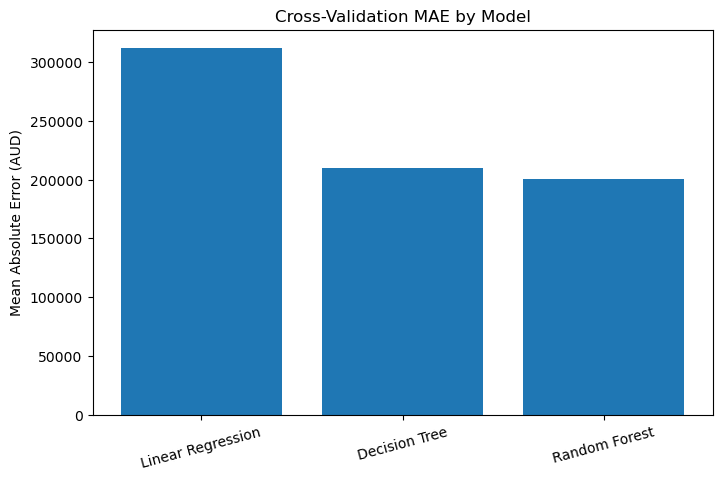

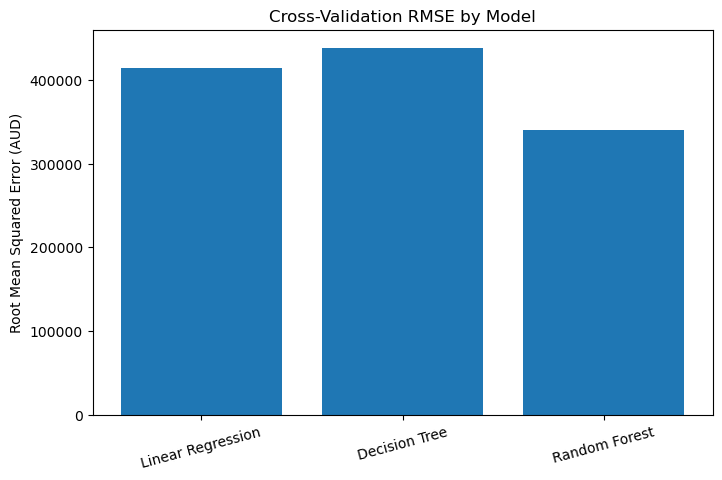

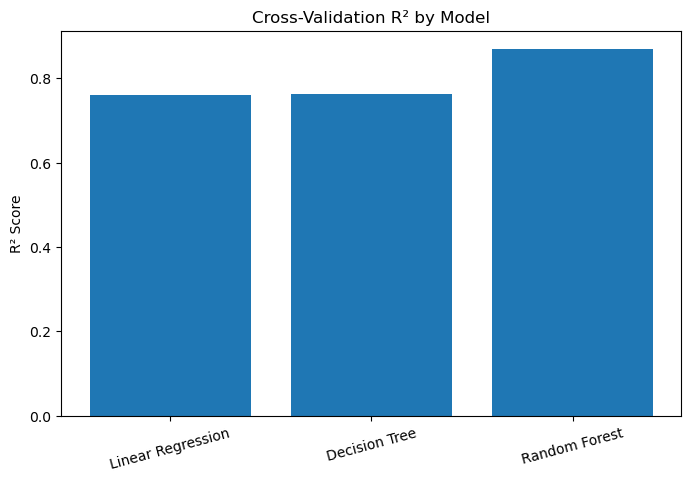

In [20]:
# Plot MAE comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.ylabel("Mean Absolute Error (AUD)")
plt.title("Cross-Validation MAE by Model")
plt.xticks(rotation=15)
plt.show()

# Plot RMSE comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("Root Mean Squared Error (AUD)")
plt.title("Cross-Validation RMSE by Model")
plt.xticks(rotation=15)
plt.show()

# Plot R² comparison
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R² Score")
plt.title("Cross-Validation R² by Model")
plt.xticks(rotation=15)
plt.show()

### Visual Model Comparison Findings

The graphs make the differences between the three models easier to see. Random Forest has the lowest MAE and RMSE, while also having the highest R² score.

The Decision Tree has a lower MAE than Linear Regression, but its RMSE is slightly higher. This suggests that it made some larger prediction errors. Overall, the graphs support the cross-validation results and show that Random Forest performed better across the three evaluation metrics.

### Checking Model Behaviour

After comparing the cross-validation results, I also wanted to check how each model performs on training data compared with unseen test data. This can help identify possible overfitting or underfitting.

I use an 80/20 train-test split and compare the training and test R² scores. If a model performs extremely well on the training data but much worse on the test data, this can be a sign of overfitting.

In [21]:
# Import train-test split and R2 metric
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

behaviour_results = []

for model_name, model in models.items():

    # Create the full pipeline
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train the model
    pipeline.fit(X_train, y_train)

    # Make predictions
    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)

    # Calculate R2 scores
    train_r2 = r2_score(y_train, train_predictions)
    test_r2 = r2_score(y_test, test_predictions)

    behaviour_results.append({
        "Model": model_name,
        "Training R2": train_r2,
        "Test R2": test_r2,
        "Difference": train_r2 - test_r2
    })

# Create results table
behaviour_df = pd.DataFrame(behaviour_results)

print("Training and Test Performance:")
display(behaviour_df.round(3))

Training and Test Performance:


,Model,Training R2,Test R2,Difference
0,Linear Regression,0.895,0.861,0.034
1,Decision Tree,0.992,0.975,0.017
2,Random Forest,0.975,0.906,0.069


### Model Behaviour Findings

The training and test results show that all three models perform reasonably well on this particular split.

Linear Regression has a training R² of 0.895 and a test R² of 0.861, with only a small difference between them. The Decision Tree has very high scores for both training and test data, with 0.992 and 0.975 respectively. Random Forest has a training R² of 0.975 and a test R² of 0.906.

Random Forest shows a slightly larger difference between its training and test scores, which suggests some overfitting may be present. However, I would not select the final model based only on this single train-test split. In the earlier 5-fold cross-validation, Random Forest had the best overall MAE, RMSE and R² results. Therefore, I still consider Random Forest the more reliable choice for this dataset.

## 8. Final Model and Prediction Error Analysis

Based on the overall cross-validation results, I selected Random Forest as the final model. It performed better across MAE, RMSE and R² during 5-fold cross-validation, even though the Decision Tree performed very well on the single train-test split.

I now use the Random Forest model to make predictions on the test set. I then compare the predicted prices with the actual sale prices to find the properties where the model made its largest errors.

In [22]:
# Create the final Random Forest pipeline
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

# Train using the training data
final_model.fit(X_train, y_train)

# Predict sale prices for the test data
y_pred = final_model.predict(X_test)

# Create a table for prediction errors
error_analysis = df_clean.loc[X_test.index, [
    "address",
    "suburb",
    "property_type",
    "bedrooms",
    "bathrooms",
    "car_spaces",
    "property_size_m2",
    "sale_price"
]].copy()

error_analysis["predicted_price"] = y_pred

error_analysis["absolute_error"] = abs(
    error_analysis["sale_price"] -
    error_analysis["predicted_price"]
)

# Find the five largest prediction errors
largest_errors = error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(5)

print("Five Largest Prediction Errors:")
display(largest_errors.round(2))

Five Largest Prediction Errors:


,address,suburb,property_type,bedrooms,bathrooms,car_spaces,property_size_m2,sale_price,predicted_price,absolute_error
70,1 Miller Street,Bondi,House,5,4,3.0,307.0,5400000,4101020.0,1298980.0
76,38 Philip Street,Bondi,House,3,2,NaN,NaN,4260000,3047130.0,1212870.0
73,5 Grove Street,Bondi,House,4,2,1.0,NaN,3850000,3384477.5,465522.5
77,3/10-12 Fletcher Street,Bondi,Apartment,2,1,1.0,NaN,2000000,1536775.0,463225.0
44,9 Kirkman Road,Blacktown,House,4,1,2.0,638.0,1070000,1221585.0,151585.0


### Largest Prediction Error Findings

The five largest prediction errors show that the model had the most difficulty with some higher-priced properties.

The largest error was for 1 Miller Street in Bondi. The actual sale price was AUD 5,400,000, while the model predicted about AUD 4,101,020. This resulted in an error of about AUD 1,298,980.

The second largest error was for 38 Philip Street in Bondi. Its actual sale price was AUD 4,260,000, while the predicted price was about AUD 3,047,130. This property also has missing parking and property size information, which may have made it harder for the model to estimate its value accurately.

Four of the five largest errors are properties in Bondi, and three of these are houses. This suggests that the model has more difficulty predicting some expensive properties in the Bondi market. These properties may have characteristics that are not fully represented by the available features, such as exact location, condition, renovations, land characteristics or other premium features.

The Blacktown property has a much smaller error of about AUD 151,585 compared with the largest Bondi errors. Overall, these results show that predictions for unusual or high-value properties should be interpreted carefully.

### Actual and Predicted Sale Prices

To understand the final model visually, I compare the actual sale prices with the predicted sale prices for the test properties.

If the predictions are close to the actual values, the points should appear close to the diagonal reference line. Properties further away from this line represent larger prediction errors.

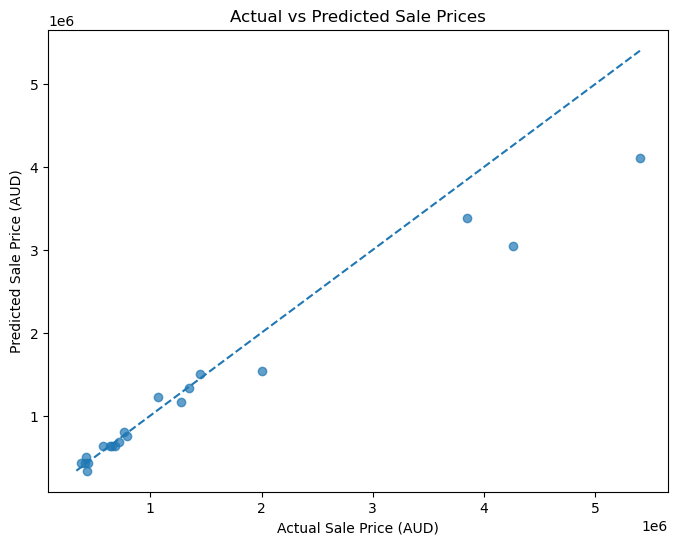

In [23]:
# Compare actual and predicted sale prices
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.7)

# Create reference line for perfect predictions
minimum_price = min(y_test.min(), y_pred.min())
maximum_price = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum_price, maximum_price],
    [minimum_price, maximum_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")
plt.title("Actual vs Predicted Sale Prices")

plt.show()

### Actual vs Predicted Price Findings

Most of the predicted prices are reasonably close to the diagonal reference line, especially for properties in the lower and middle price ranges. This shows that the model is generally able to follow the actual sale prices.

However, some of the most expensive properties are further away from the reference line. In particular, the model tends to underestimate some high-priced properties. This matches the previous error analysis, where the largest prediction errors were mainly expensive properties in Bondi.

Overall, the graph shows that the model performs reasonably well for most properties in the test set, but it is less reliable for unusual and very expensive properties.

## 9. Web Application Development

After selecting Random Forest as the final model, the next step is to make the prediction system easier to use. I will create a simple web application where a user can enter property information and receive an estimated sale price.

The application will use the same preprocessing steps and Random Forest model developed in this notebook. The required engineered features will be calculated automatically from the information entered by the user.

### Saving the Final Model

Before creating the web application, I save the final Random Forest pipeline as a separate file. The saved pipeline includes both the preprocessing steps and the trained regression model.

I train the final model using all 100 properties because the model comparison and evaluation stages have already been completed. This allows the application to use all available data when producing future predictions.

In [24]:
import joblib

# Train the selected final model using the full dataset
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

final_model.fit(X, y)

# Save the complete pipeline
joblib.dump(final_model, "housing_price_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


### Model Saving Result

The final Random Forest pipeline was trained using the full dataset and saved successfully. The saved file contains both the preprocessing steps and the trained model, so the same process can be used when a user enters property information through the web application.

### Web Application Result

The Streamlit web application was created and tested successfully. The user can select the suburb and property type and enter information such as bedrooms, bathrooms, car spaces, property size, sale year and sale month.

The application automatically creates the additional engineered features required by the model and then uses the saved Random Forest pipeline to estimate the sale price.

For one test, I entered a two-bedroom apartment in Parramatta with one bathroom, one car space and a property size of 100 m². The application returned an estimated sale price of AUD 559,732.

The application also includes a message explaining that the prediction is only an estimate based on the collected dataset and should not be treated as a professional property valuation.

## 10. Reflection, Limitations and Future Improvements

After completing the full machine learning workflow, I reflected on the main challenges, limitations and possible improvements of the project.

The project involved manually collecting property data, exploring and cleaning the dataset, creating additional features, comparing regression models, investigating prediction errors and finally using the selected model in a simple web application.

### Project Reflection

One of the biggest challenges I had in this project was collecting the property data manually. I managed to collect 100 sold properties from the three suburbs, but not every listing had all the information I needed. For example, property size was missing for 66 properties and car-space information was missing for 13 properties. I did not want to remove all of these properties because I would lose a large amount of my dataset, so I handled the missing numerical values during preprocessing.

Before doing the analysis, I thought suburb, property type and property size would have the strongest influence on sale price. The results supported my expectations about suburb and property type, but property size was different from what I expected. For the properties where size information was available, the correlation with sale price was only 0.209. This helped me understand that what I expect before analysing the data may not always match the actual results.

Another thing I noticed was that the model struggled more with some of the expensive Bondi properties. Most of the largest prediction errors came from Bondi, and the model underestimated some of the very expensive houses. I think one reason for this is that the dataset does not include everything that can affect the value of a property. Things like the exact location, condition of the house, renovations, land details and other special features could make a big difference in the actual sale price.

The dataset itself is also quite small because it only contains 100 properties from Parramatta, Blacktown and Bondi. Because of this, I would not expect the model to represent the whole Sydney housing market. The properties were also not evenly spread across every month or property type, which could create some bias in the results. For example, there are many more apartments than some of the other property types.

If I continued this project, I would collect a much larger dataset from more Sydney suburbs and across a longer period of time. I would also try to collect more complete property information, especially property size, land size, condition and renovation details. I would also spend more time tuning and testing the models to see if the predictions could be improved.

Overall, this project showed me that machine learning is not only about choosing the model with the best score. The quality of the data, missing information, unusual properties and prediction errors can all affect how useful a model actually is. Creating the Streamlit application also helped me see how a machine learning model can be turned into something that a user can actually interact with.

## 11. Conclusion

In this project, I went through the full machine learning process using housing data collected from Parramatta, Blacktown and Bondi. I explored and prepared the data, created additional features and compared Linear Regression, Decision Tree and Random Forest models.

From the 5-fold cross-validation results, Random Forest performed the best overall, with an R² of 0.869 and lower MAE and RMSE values than the other models. However, the error analysis also showed that the model was less reliable for some very expensive Bondi properties.

Finally, I used the trained Random Forest model in a Streamlit web application that can estimate a sale price from property information entered by a user. Overall, the project helped me understand the complete process from collecting raw data to evaluating a model and using it in a working application.

## 12. Web Application Instructions

The web application was developed using Streamlit.

To run the application:

1. Keep `app.py` and `housing_price_model.pkl` in the same folder.
2. Open a terminal in the project folder.
3. Run the command `streamlit run app.py`.
4. Open the local URL provided by Streamlit in a web browser.
5. Enter the property details, including suburb, property type, bedrooms, bathrooms, car spaces, property size, sale year and sale month.
6. Click the `Predict Sale Price` button.
7. The application will display the estimated sale price in AUD.

The application was tested successfully using a Parramatta apartment example and returned an estimated sale price of AUD 559,732.

## 13. Data Sources and References

The housing dataset used in this project was manually created using publicly available sold-property information from Australian real estate websites.

The main information collected for each property included the address, suburb, sale price, sale date, property type, bedrooms, bathrooms, car spaces and property size where this information was available.

Properties without a disclosed sale price were not included because sale price is the target variable required for the regression models. When information such as property size or parking was unavailable, I kept it as missing instead of creating an estimated value.

Main property information sources:

- Realestate.com.au – sold-property listings
- Domain – sold-property listings

The final dataset contains 100 sold properties from Parramatta, Blacktown and Bondi.

## 14. GenAI Acknowledgement

I used ChatGPT during this project as a support tool for planning the project structure, understanding some machine learning concepts, troubleshooting code and improving the clarity of my writing.

I reviewed the suggestions and outputs before using them and made changes based on my own project, dataset and results. The final analysis, model evaluation and reflection are based on the results produced from my own project dataset and notebook.